In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pp5.stats.mht import mht_bh

In [2]:
BASE_PATH = Path("../out/pnas-2026/").resolve()

RESULTS_DIR = BASE_PATH / "results"
assert RESULTS_DIR.is_dir(), f"Results directory {RESULTS_DIR} does not exist"

OUT_DIR = BASE_PATH / "figs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.absolute()

PosixPath('/Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs')

## Load analyis results

In [3]:
# Data

LABELLED_TAGS = {
    ### torustest, w2torus metric (no permutation test)
    "w2torus(2-random); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=none-noself",
    "w2torus(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=none-noself",
    "w2torus(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=0-nmax=0-torus_p_nproj=4_randproj=False-cr=aa_ss-noself",
    #
    ### Permutation test with w2torus metric
    #
    "w2torus-perm(2-random); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=none-noself",
    "w2torus-perm(2-random); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=2_randproj=True-cr=aa_ss-noself",
    #
    "w2torus-perm(4-fixed); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=none-noself",
    "w2torus-perm(4-fixed); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-torus_perm_nproj=4_randproj=False-cr=aa_ss-noself",
    ### Permutation test with KDE-L1 metric
    # #
    "kde-l1(bw=10.0); none": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_none-noself",
    "kde-l1(bw=10.0); aa_ss": "pointwise_cdist-manual-t_1-bs_1-k_5000-nmax_0-kde_g_10.0-cr_aa_ss-noself",
    # #
    "kde-l1(bw=CV); none": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=none-noself",
    "kde-l1(bw=CV); aa_ss": "pointwise_cdist-t=1-bs=1-k=5000-nmax=0-kde_g_bw=cv-cr=aa_ss-noself",
}

PVALS_FILENAME = "pvals/cc-pvals.csv"

LABELLED_CSV_PATHS = {
    label: Path(RESULTS_DIR) / tag / PVALS_FILENAME
    for label, tag in LABELLED_TAGS.items()
}

In [4]:
for _, _csv_path in LABELLED_CSV_PATHS.items():
    assert _csv_path.is_file(), str(_csv_path)

In [5]:
_csv_path = next(iter(LABELLED_CSV_PATHS.values()))
_df = pd.read_csv(_csv_path)
_df.head()

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000,0.452742,True
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000,0.369836,True
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026,0.193612,False
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031,0.218664,False
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031,0.207236,False


In [6]:
def _get_stat_test_type(k: str) -> str:
    return k.split(";")[0].strip()


def _get_randomization_type(k: str) -> str:
    return k.split(";")[1].strip()


### Load all pval csvs into single df

In [7]:
pval_dfs = []

for run_label, csv_path in LABELLED_CSV_PATHS.items():
    df = pd.read_csv(csv_path).copy()

    stat_test_name = _get_stat_test_type(run_label)
    randomization_type = _get_randomization_type(run_label)

    df["stat_test"] = stat_test_name
    df["codon_randomization"] = randomization_type
    pval_dfs.append(df)

In [8]:
df_all_pvals = pd.concat(pval_dfs, axis=0)
df_all_pvals.to_csv(OUT_DIR / "pvals.csv", index=False)
df_all_pvals

,condition_group,subgroup1,subgroup2,n1,n2,phi1_mean,psi1_mean,phi2_mean,psi2_mean,d12,pval,ddist,significant,stat_test,codon_randomization
0,HELIX,L-CTC,L-CTG,528,2812,-66.176835,-37.717240,-65.223519,-39.349970,1.890666,0.000000,0.452742,True,w2torus(2-random),none
1,HELIX,L-CTC,L-TTG,528,599,-66.176835,-37.717240,-65.148195,-39.742460,2.271478,0.000000,0.369836,True,w2torus(2-random),none
2,HELIX,P-CCC,P-CCT,92,151,-59.370040,-35.431395,-58.398541,-36.500818,1.444810,0.026000,0.193612,False,w2torus(2-random),none
3,HELIX,G-GGA,G-GGT,153,462,-63.320628,-39.383827,-60.929911,-42.138466,3.647405,0.031000,0.218664,False,w2torus(2-random),none
4,HELIX,Q-CAA,Q-CAG,828,1629,-65.262840,-38.494280,-65.033755,-38.954806,0.514357,0.031000,0.207236,False,w2torus(2-random),none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,TURN,S-TCA,S-TCC,156,224,-73.889062,-9.825850,-72.864800,-6.070989,3.892056,0.980392,0.411151,False,kde-l1(bw=CV),aa_ss
344,TURN,R-AGA,R-CGA,37,88,-70.794883,8.325403,-66.554292,1.724830,7.845392,0.990099,0.468606,False,kde-l1(bw=CV),aa_ss
345,TURN,G-GGC,G-GGT,1606,1319,80.869529,1.705079,79.732616,2.330890,1.297771,0.990099,0.110475,False,kde-l1(bw=CV),aa_ss
346,TURN,S-AGC,S-AGT,388,224,-73.538577,-6.302294,-72.289923,-5.694079,1.388907,1.000000,0.113379,False,kde-l1(bw=CV),aa_ss


In [9]:
stat_test_names = sorted(df_all_pvals["stat_test"].unique())
randomization_names = sorted(df_all_pvals["codon_randomization"].unique())

stat_test_names, randomization_names

(['kde-l1(bw=10.0)',
  'kde-l1(bw=CV)',
  'w2torus(2-random)',
  'w2torus(4-fixed)',
  'w2torus-perm(2-random)',
  'w2torus-perm(4-fixed)'],
 ['aa_ss', 'none'])


## Compute number of rejections across all AAs in each SS

BH multiple-testing correction per (stat_test * randomization * SS) group.

For each combination we pool all codon-pair p-values within that SS class,
apply the Benjamini–Hochberg procedure at level FDR, and record:
- bh_pvalue_threshold: the BH threshold p* (reject hypotheses with p ≤ p*)
- n_rejected: number of codon pairs whose p-value ≤ p*
- n_hypotheses: total number of codon pairs tested in the group (should be 87 for all groups)

In [10]:
import re

FDR = 0.05

# Human-readable display names for each statistical test type, randomization strategy,
# and secondary-structure class used in plot labels and table output.
test_type_display = {
    "kde-l1": "Permutation test (KDE-L1)",
    "w2torus": "Torus test (Projected Wasserstein)",
    "w2torus-perm": "Permutation test (Projected Wasserstein)",
}
randomization_display = {
    "aa_ss": "Randomized control",
    "none": "Real data",
}
ss_display = {
    "HELIX": "HELIX",
    "SHEET": "SHEET",
    "TURN": "TURN",
    "OTHER": "OTHER",
}


In [11]:
def _parse_stat_test_name(stat_test_name: str) -> tuple[str, str]:
    """Split a label like 'w2torus(2-random)' into ('w2torus', '2-random').

    Returns (test_type, test_params); test_params is an empty string when no
    parenthesized parameters are present.
    """
    match = re.fullmatch(
        r"\s*(?P<test_type>[^()]+?)(?:\((?P<test_params>.*)\))?\s*", stat_test_name
    )
    if not match:
        raise ValueError(f"Could not parse stat test label: {stat_test_name}")

    test_type = match.group("test_type").strip()
    test_params = (match.group("test_params") or "").strip()
    return test_type, test_params


In [12]:
rejections_df_entries = []

for (stat_test_name, randomization_type, ss), df_group in df_all_pvals.groupby(
    by=["stat_test", "codon_randomization", "condition_group"], sort=False
):
    pvals = df_group["pval"].to_numpy()
    m = len(pvals)  # total number of hypotheses (codon pairs) in this SS class
    if m < 1:
        raise RuntimeError("Empty p-value group encountered")

    # BH threshold: reject null hypotheses whose p-value is at or below this value.
    p_thresh = mht_bh(q=FDR, pvals=pvals)
    pv_lt_thresh = pvals <= p_thresh  # boolean mask of rejected hypotheses
    n_rejected = int(np.sum(pv_lt_thresh))  # number of rejections out of m

    df_group_rejected = df_group[pv_lt_thresh]
    assert len(df_group_rejected) == n_rejected

    # Collect the rejected codon-pair labels for inspection / downstream use.
    rejected_pairs = [
        f"{c1}:{c2}"
        for c1, c2 in zip(
            df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
        )
    ]
    rejected_pairs_str = str.join("; ", rejected_pairs)

    test_type, test_params = _parse_stat_test_name(stat_test_name)
    rejections_df_entries.append(
        {
            "stat_test": stat_test_name,
            "test_type": test_type,
            "test_params": test_params,
            "test_family": test_type_display.get(test_type, test_type),
            "codon_randomization": randomization_type,
            "randomization_label": randomization_display.get(
                randomization_type, randomization_type
            ),
            "SS": ss,
            "n_hypotheses": m,  # total codon-pair tests in this SS class
            "FDR": FDR,
            "bh_pvalue_threshold": p_thresh,
            "n_rejected": n_rejected,
            "rejected_pairs": rejected_pairs_str,
        }
    )

df_rejections = pd.DataFrame(rejections_df_entries)
df_rejections = df_rejections.sort_values(
    by=["stat_test", "codon_randomization", "SS"], kind="stable"
).reset_index(drop=True)
df_rejections.head()


,stat_test,test_type,test_params,test_family,codon_randomization,randomization_label,SS,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,HELIX,87,0.05,0.000000,0,
1,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,OTHER,87,0.05,0.000000,0,
2,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,SHEET,87,0.05,0.000000,0,
3,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),aa_ss,Randomized control,TURN,87,0.05,0.000000,0,
4,kde-l1(bw=10.0),kde-l1,bw=10.0,Permutation test (KDE-L1),none,Real data,HELIX,87,0.05,0.001149,2,L-CTC:L-TTG; L-CTC:L-CTG


In [13]:
df_rejections.to_csv(OUT_DIR / f"rejections-{FDR=:.2f}.csv", index=False)



## Plot pval CDFs per SS type

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pp5.plot import PP5_MPL_STYLE

ss_colors = {
    "HELIX": "#e41a1c",
    "SHEET": "#377eb8",
    "TURN": "#4daf4a",
    "OTHER": "#984ea3",
}


In [15]:
# ── Build an ordered table of unique stat-test configurations ─────────────────
# Iterate over LABELLED_TAGS to collect one entry per unique stat-test name
# (ignoring the randomization suffix), preserving the order of first appearance.
plot_rows = []
seen_stat_tests = set()
for run_label in LABELLED_TAGS:
    stat_test_name = _get_stat_test_type(run_label)
    if stat_test_name in seen_stat_tests:
        continue
    seen_stat_tests.add(stat_test_name)

    test_type, test_params = _parse_stat_test_name(stat_test_name)
    plot_rows.append(
        {
            "stat_test": stat_test_name,  # full label, e.g. "w2torus(2-random)"
            "test_type": test_type,  # base method, e.g. "w2torus"
            "test_params": test_params,  # parameter string, e.g. "2-random"
            "test_family": test_type_display.get(test_type, test_type),  # display name
        }
    )

df_plot_rows = pd.DataFrame(plot_rows)

# Assign a rank to each test_type based on the preferred display order defined in
# test_type_display; unknown types are placed after all known types.
test_type_rank = {name: idx for idx, name in enumerate(test_type_display)}
df_plot_rows["type_rank"] = df_plot_rows["test_type"].map(
    lambda name: test_type_rank.get(name, len(test_type_rank))
)
# Preserve within-family appearance order so rows within a family stay consistent.
df_plot_rows["appearance_rank"] = np.arange(len(df_plot_rows))
df_plot_rows = df_plot_rows.sort_values(
    by=["type_rank", "appearance_rank"], kind="stable"
).reset_index(drop=True)

# ── Ordered axis lists for the plot grid ──────────────────────────────────────
# stat_test_order  : row order in the figure (one row per stat-test configuration)
# randomization_order: column order (preferred order from display dict, then any extras)
# ss_order         : line order within each panel (HELIX, SHEET, TURN, OTHER first)
stat_test_order = df_plot_rows["stat_test"].tolist()
randomization_order = [
    name
    for name in randomization_display
    if name in set(df_all_pvals["codon_randomization"])
]
randomization_order += [
    name
    for name in df_all_pvals["codon_randomization"].unique()
    if name not in set(randomization_order)
]
ss_order = [ss for ss in ss_display if ss in set(df_all_pvals["condition_group"])]
ss_order += [
    ss for ss in df_all_pvals["condition_group"].unique() if ss not in set(ss_order)
]


In [16]:
# Total number of rejected hypotheses per (stat_test, codon_randomization) panel
panel_rejections = df_rejections.groupby(
    by=["stat_test", "codon_randomization"], sort=False
)["n_rejected"].sum()

# Row indices grouped by test family, used later to draw dividers between families
family_row_groups = [
    group.index.to_list()
    for _, group in df_plot_rows.groupby("test_family", sort=False)
]


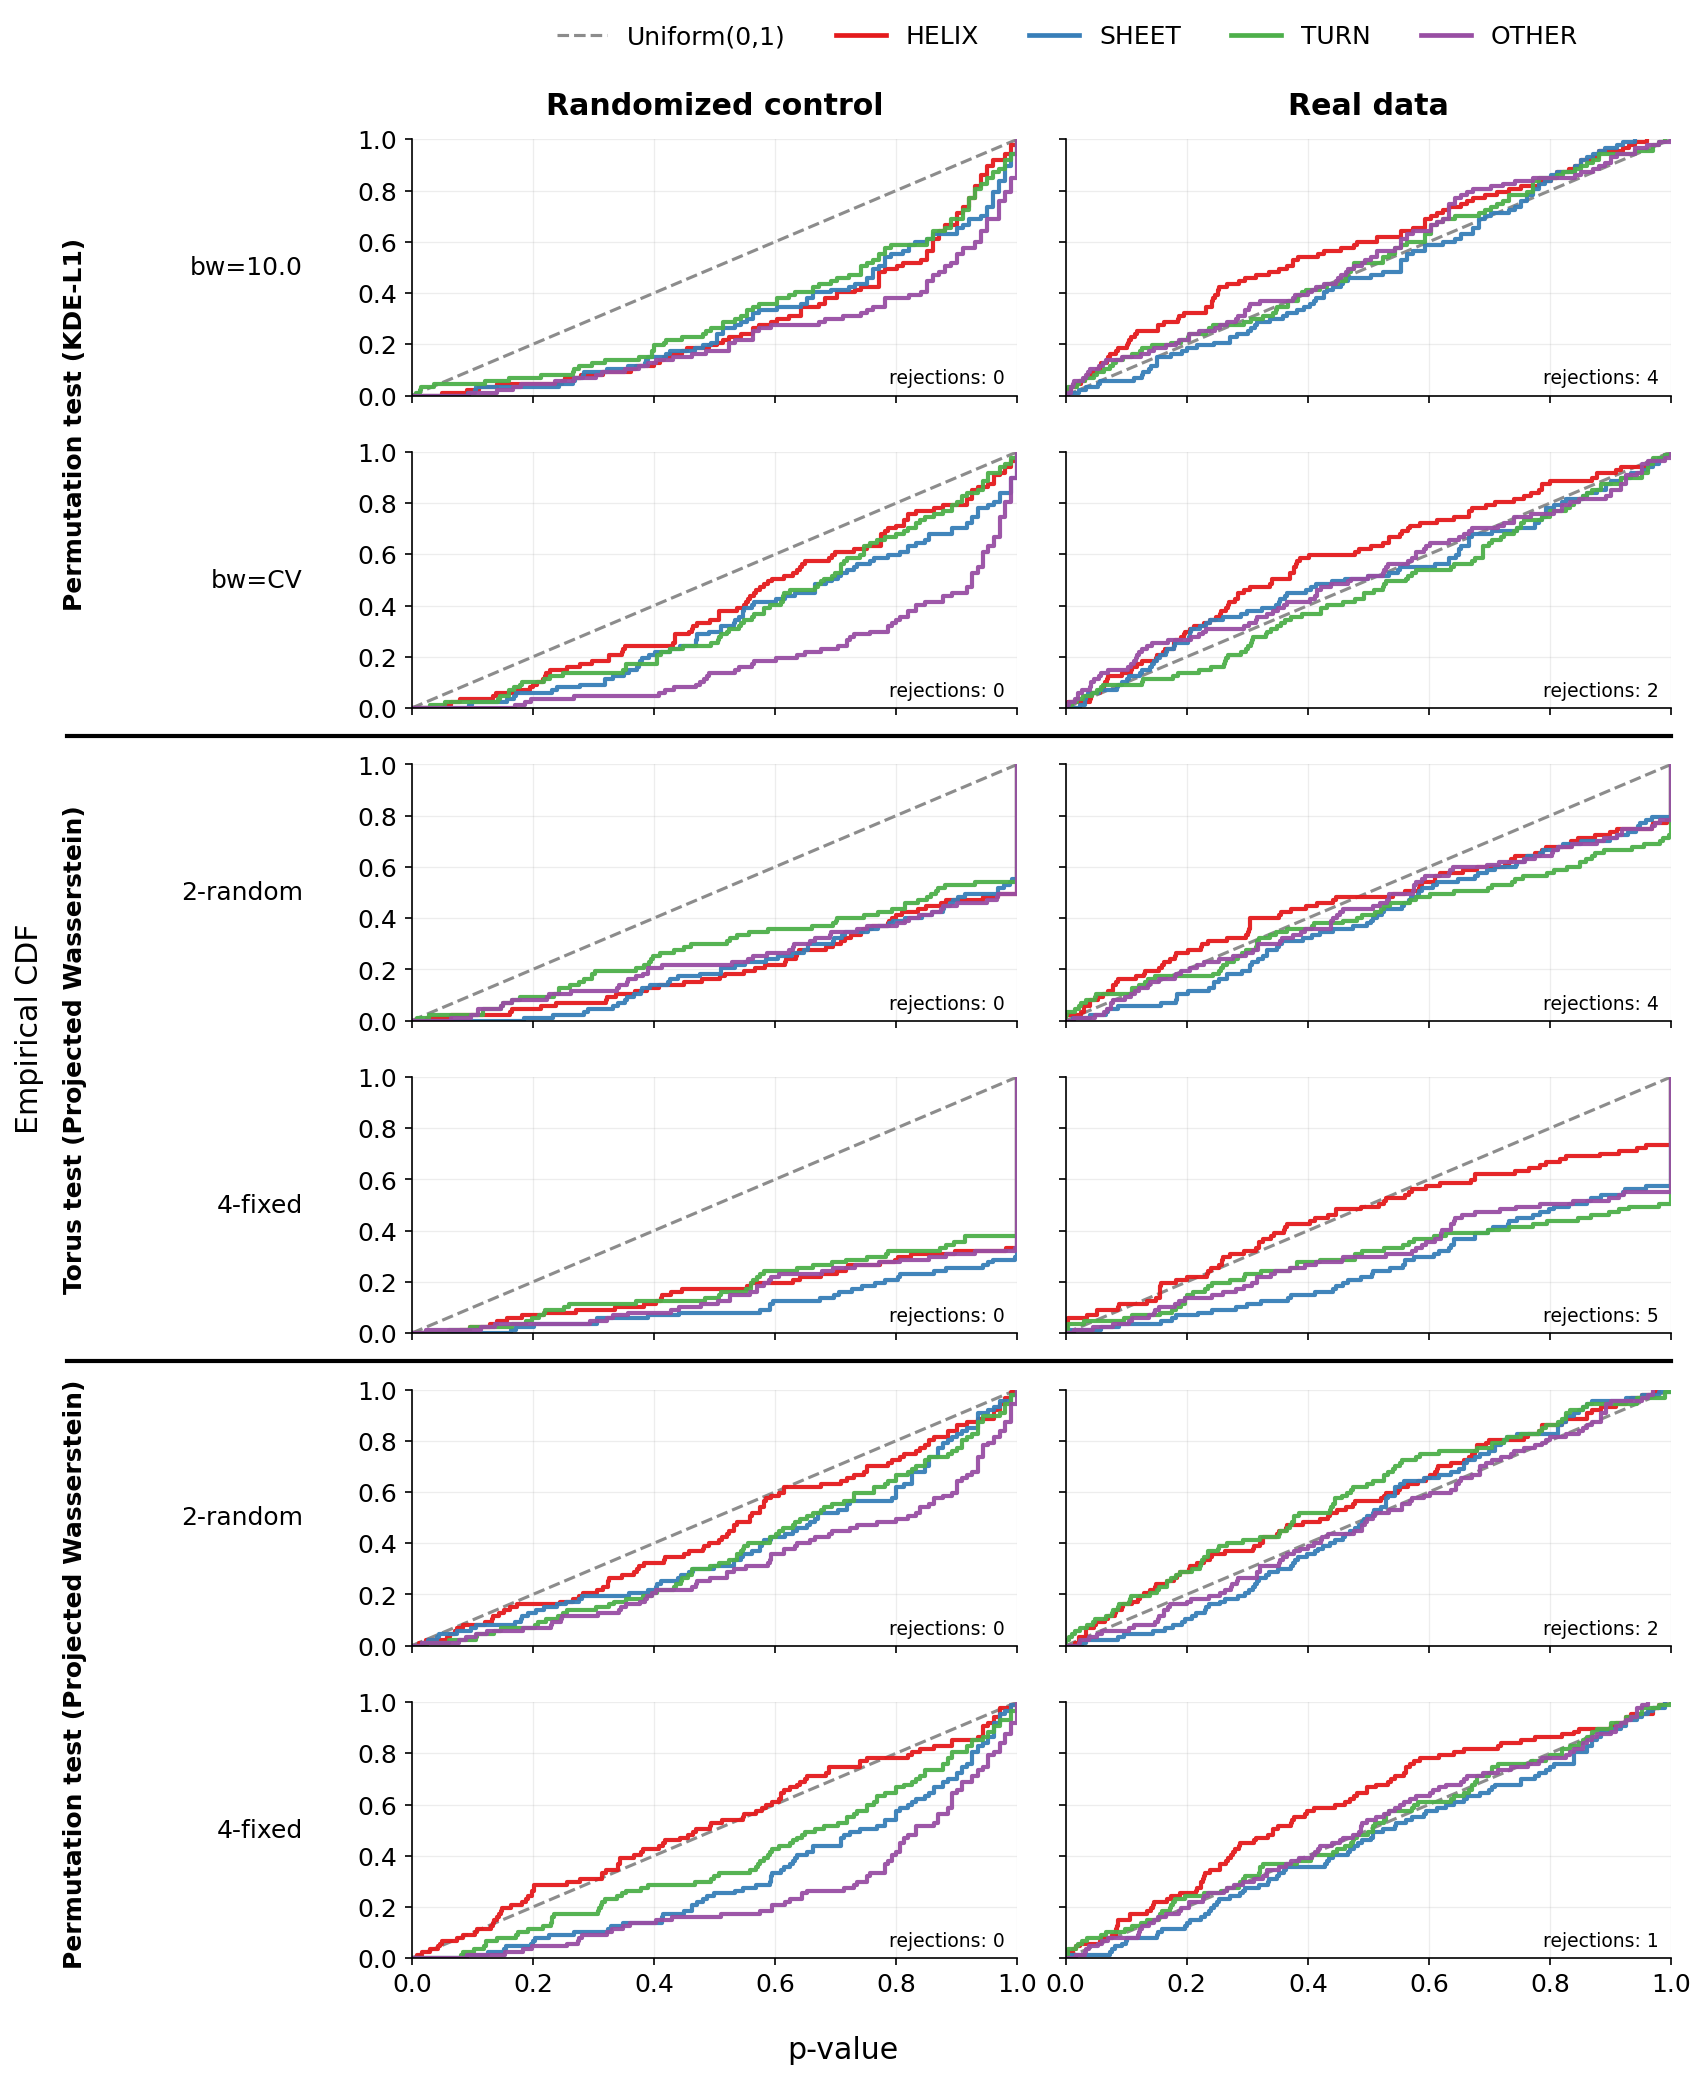

In [17]:
plt.close("all")
with mpl.style.context(PP5_MPL_STYLE):
    nrows, ncols = len(stat_test_order), len(randomization_order)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(11.5, 2.35 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    fig.subplots_adjust(
        left=0.25, right=0.98, bottom=0.06, top=0.92, hspace=0.22, wspace=0.08
    )

    # Column headers: randomization type label at the top of each column
    for col_idx, randomization_type in enumerate(randomization_order):
        axes[0, col_idx].set_title(
            randomization_display.get(randomization_type, randomization_type),
            fontweight="bold",
            pad=12,
        )

    # Row labels: stat-test / parameter string to the left of each row
    for row_idx, row in df_plot_rows.iterrows():
        row_label = row["test_params"] or row["stat_test"]
        axes[row_idx, 0].annotate(
            row_label,
            xy=(-0.18, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=12,
            annotation_clip=False,
        )

    # Legend handles: dashed line for the Uniform(0,1) reference + one line per SS class
    legend_handles = [
        Line2D([0], [0], color="0.55", ls="--", lw=1.5, label="Uniform(0,1)"),
        *[
            Line2D(
                [0],
                [0],
                color=ss_colors.get(ss, "#444444"),
                lw=2.25,
                label=ss_display.get(ss, ss.title()),
            )
            for ss in ss_order
        ],
    ]

    # Main panel loop: one panel per (stat_test, randomization_type) combination
    for row_idx, stat_test_name in enumerate(stat_test_order):
        for col_idx, randomization_type in enumerate(randomization_order):
            idx = (df_all_pvals["stat_test"] == stat_test_name) & (
                df_all_pvals["codon_randomization"] == randomization_type
            )
            df_panel = df_all_pvals[idx]
            assert len(df_panel)

            ax = axes[row_idx, col_idx]
            # Diagonal reference line y=x corresponding to Uniform(0,1) p-values
            ax.plot(
                [0.0, 1.0],
                [0.0, 1.0],
                ls="--",
                color="0.55",
                lw=1.5,
                zorder=1,
            )

            # Empirical CDF of p-values for each secondary-structure class
            for ss in ss_order:
                df_group = df_panel[df_panel["condition_group"] == ss]
                if df_group.empty:
                    continue

                pvals = np.sort(df_group["pval"].to_numpy())
                m = len(pvals)
                x = np.concatenate(([0.0], pvals))
                y = np.arange(0, m + 1) / m
                ax.step(
                    x,
                    y,
                    where="post",
                    color=ss_colors.get(ss, "#444444"),
                    lw=2.0,
                    alpha=0.95,
                    zorder=2,
                )

            # Annotation in the bottom-right corner with the rejection count for this panel
            n_rejected = int(panel_rejections.loc[(stat_test_name, randomization_type)])
            ax.text(
                0.98,
                0.03,
                f"rejections: {n_rejected}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=9,
                # bbox={"facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
            )
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.0)
            ax.set_xticks(np.linspace(0.0, 1.0, 6))
            ax.set_yticks(np.linspace(0.0, 1.0, 6))
            ax.grid(alpha=0.22, linewidth=0.6)
            ax.spines[["top", "right"]].set_visible(False)

    # Rotated family-name label centered vertically over its group of rows
    for _, group in df_plot_rows.groupby("test_family", sort=False):
        rows = group.index.to_list()
        top = axes[rows[0], 0].get_position().y1
        bottom = axes[rows[-1], 0].get_position().y0
        y_center = 0.5 * (top + bottom)
        fig.text(
            0.055,
            y_center,
            group.iloc[0]["test_family"],
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold",
        )

    # Horizontal divider line between consecutive test-family groups
    for upper_rows, lower_rows in zip(family_row_groups, family_row_groups[1:]):
        upper_row = axes[upper_rows[-1], 0].get_position()
        lower_row = axes[lower_rows[0], 0].get_position()
        y = 0.5 * (upper_row.y0 + lower_row.y1)
        fig.add_artist(
            Line2D(
                [0.05, 0.98],
                [y, y],
                transform=fig.transFigure,
                color="black",
                lw=2.0,
            )
        )

    # Shared legend placed above the plot area
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.63, 0.985),
        ncol=len(legend_handles),
        frameon=False,
    )
    fig.supxlabel("p-value")
    fig.supylabel("Empirical CDF")

plt.show()

In [18]:
fig.savefig(OUT_DIR / f"pvals_cdf-{FDR=:.2f}.pdf", bbox_inches="tight")

## Repeat BH-q test but only within the same AA

BH multiple-testing correction per (SS * AA * stat_test * randomization).

In the previous section we pooled all codon pairs within an SS class,
here BH is applied separately within each amino acid.  This is a finer-grained
correction: the family of hypotheses for each AA consists only of the codon-pair
tests for that AA.


In [19]:
aa1_col, aa2_col = [df_all_pvals[f"subgroup{j}"].str.get(0) for j in ("1", "2")]

# Sanity: all tests are comparing codons from the same AA
assert np.all(aa1_col == aa2_col)

In [20]:
print(f"{len(aa1_col.unique())=}")
print(sorted(aa1_col.unique()))

len(aa1_col.unique())=18
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'Y']


In [21]:
rejections_aa_df_entries = []

# aa1_col is a Series (first character of subgroup1), passed directly to groupby
# so pandas treats it as a grouping key without adding it as a DataFrame column.
for (ss, aa, stat_test_name, randomization_type), df_group in df_all_pvals.groupby(
    by=["condition_group", aa1_col, "stat_test", "codon_randomization"]
):
    pvals = df_group["pval"].to_numpy()
    m = len(pvals)  # number of codon-pair hypotheses for this AA in this SS
    if m < 1:
        raise RuntimeError("Empty?")

    # mht_bh() requires m >= 2; for AAs with a single codon pair (m == 1) there is
    # nothing to correct for multiplicity — treat it as a plain significance test
    # at the same nominal FDR level.
    if m > 1:
        p_thresh = mht_bh(q=FDR, pvals=pvals)  # BH threshold p* for this AA group
    else:
        p_thresh = FDR  # single hypothesis: reject if p <= FDR directly

    pv_lt_thresh = pvals <= p_thresh  # boolean mask: True where null is rejected
    n_rejected = int(np.sum(pv_lt_thresh))  # count of rejected hypotheses out of m

    df_group_rejected = df_group[pv_lt_thresh]
    assert len(df_group_rejected) == n_rejected

    # Collect the rejected codon-pair labels (e.g. "AAA:AAG") for downstream use.
    rejected_pairs = [
        f"{c1}:{c2}"
        for c1, c2 in zip(
            df_group_rejected["subgroup1"], df_group_rejected["subgroup2"]
        )
    ]
    rejected_pairs_str = str.join("; ", rejected_pairs)

    rejections_aa_df_entries.append(
        {
            "stat_test": stat_test_name,
            "codon_randomization": randomization_type,
            "SS": ss,
            "AA": aa,
            "n_hypotheses": m,  # codon-pair tests for this AA in this SS
            "FDR": FDR,
            "bh_pvalue_threshold": p_thresh,
            "n_rejected": n_rejected,  # rejections out of n_hypotheses
            "rejected_pairs": rejected_pairs_str,
        }
    )


In [22]:
df_rejections_aa = pd.DataFrame(rejections_aa_df_entries)
df_rejections_aa = df_rejections_aa.sort_values(
    by=["stat_test", "codon_randomization", "SS", "AA", "n_hypotheses"]
)

df_rejections_aa.to_csv(OUT_DIR / f"rejections_aa-{FDR=:.2f}.csv", index=False)
df_rejections_aa

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),aa_ss,HELIX,A,6,0.05,0.00,0,
12,kde-l1(bw=10.0),aa_ss,HELIX,C,1,0.05,0.05,0,
24,kde-l1(bw=10.0),aa_ss,HELIX,D,1,0.05,0.05,0,
36,kde-l1(bw=10.0),aa_ss,HELIX,E,1,0.05,0.05,0,
48,kde-l1(bw=10.0),aa_ss,HELIX,F,1,0.05,0.05,0,
...,...,...,...,...,...,...,...,...,...
815,w2torus-perm(4-fixed),none,TURN,R,15,0.05,0.00,0,
827,w2torus-perm(4-fixed),none,TURN,S,15,0.05,0.00,0,
839,w2torus-perm(4-fixed),none,TURN,T,6,0.05,0.00,0,
851,w2torus-perm(4-fixed),none,TURN,V,6,0.05,0.00,0,


### Check for any rejections in the control data

In [23]:
idx_rejected_null = (df_rejections_aa["codon_randomization"] == "aa_ss") & (
    df_rejections_aa["n_rejected"] > 0
)
df_rejections_aa[idx_rejected_null]

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
832,w2torus(2-random),aa_ss,TURN,T,6,0.05,0.008333,1,T-ACA:T-ACT
680,w2torus-perm(2-random),aa_ss,TURN,D,1,0.05,0.050000,1,D-GAC:D-GAT
202,w2torus-perm(4-fixed),aa_ss,HELIX,V,6,0.05,0.008333,1,V-GTA:V-GTC


### Check for any rejections in the real data

In [24]:
idx_rejected_real = (df_rejections_aa["codon_randomization"] == "none") & (
    df_rejections_aa["n_rejected"] > 0
)
df_rejections_aa[idx_rejected_real]

,stat_test,codon_randomization,SS,AA,n_hypotheses,FDR,bh_pvalue_threshold,n_rejected,rejected_pairs
109,kde-l1(bw=10.0),none,HELIX,L,15,0.05,0.006667,2,L-CTC:L-TTG; L-CTC:L-CTG
373,kde-l1(bw=10.0),none,OTHER,R,15,0.05,0.003333,1,R-AGA:R-CGC
613,kde-l1(bw=10.0),none,SHEET,T,6,0.05,0.008333,1,T-ACC:T-ACG
649,kde-l1(bw=10.0),none,TURN,A,6,0.05,0.008333,1,A-GCG:A-GCT
781,kde-l1(bw=10.0),none,TURN,P,6,0.05,0.025000,3,P-CCC:P-CCG; P-CCG:P-CCT; P-CCA:P-CCG
111,kde-l1(bw=CV),none,HELIX,L,15,0.05,0.003333,1,L-CTC:L-TTG
243,kde-l1(bw=CV),none,OTHER,D,1,0.05,0.050000,1,D-GAC:D-GAT
351,kde-l1(bw=CV),none,OTHER,P,6,0.05,0.008333,1,P-CCC:P-CCG
375,kde-l1(bw=CV),none,OTHER,R,15,0.05,0.003333,1,R-AGA:R-CGC
579,kde-l1(bw=CV),none,SHEET,Q,1,0.05,0.050000,1,Q-CAA:Q-CAG


In [25]:
# Sanity: Total number of hypotheses per SS should be 87
_df_rejections_aa_groups = df_rejections_aa.groupby(
    by=["stat_test", "codon_randomization", "SS"]
)
# _df_rejections_aa_groups["n_hypotheses"].agg("sum")
_df_total_hypotheses_per_aa = _df_rejections_aa_groups.aggregate(
    total_hypotheses=pd.NamedAgg(column="n_hypotheses", aggfunc="sum")
).reset_index()

assert np.all(_df_total_hypotheses_per_aa["total_hypotheses"] == 87), (
    "Total hypotheses per SS should be 87"
)
_df_total_hypotheses_per_aa.head()

,stat_test,codon_randomization,SS,total_hypotheses
0,kde-l1(bw=10.0),aa_ss,HELIX,87
1,kde-l1(bw=10.0),aa_ss,OTHER,87
2,kde-l1(bw=10.0),aa_ss,SHEET,87
3,kde-l1(bw=10.0),aa_ss,TURN,87
4,kde-l1(bw=10.0),none,HELIX,87


### Plot num rejections per AA for each test type

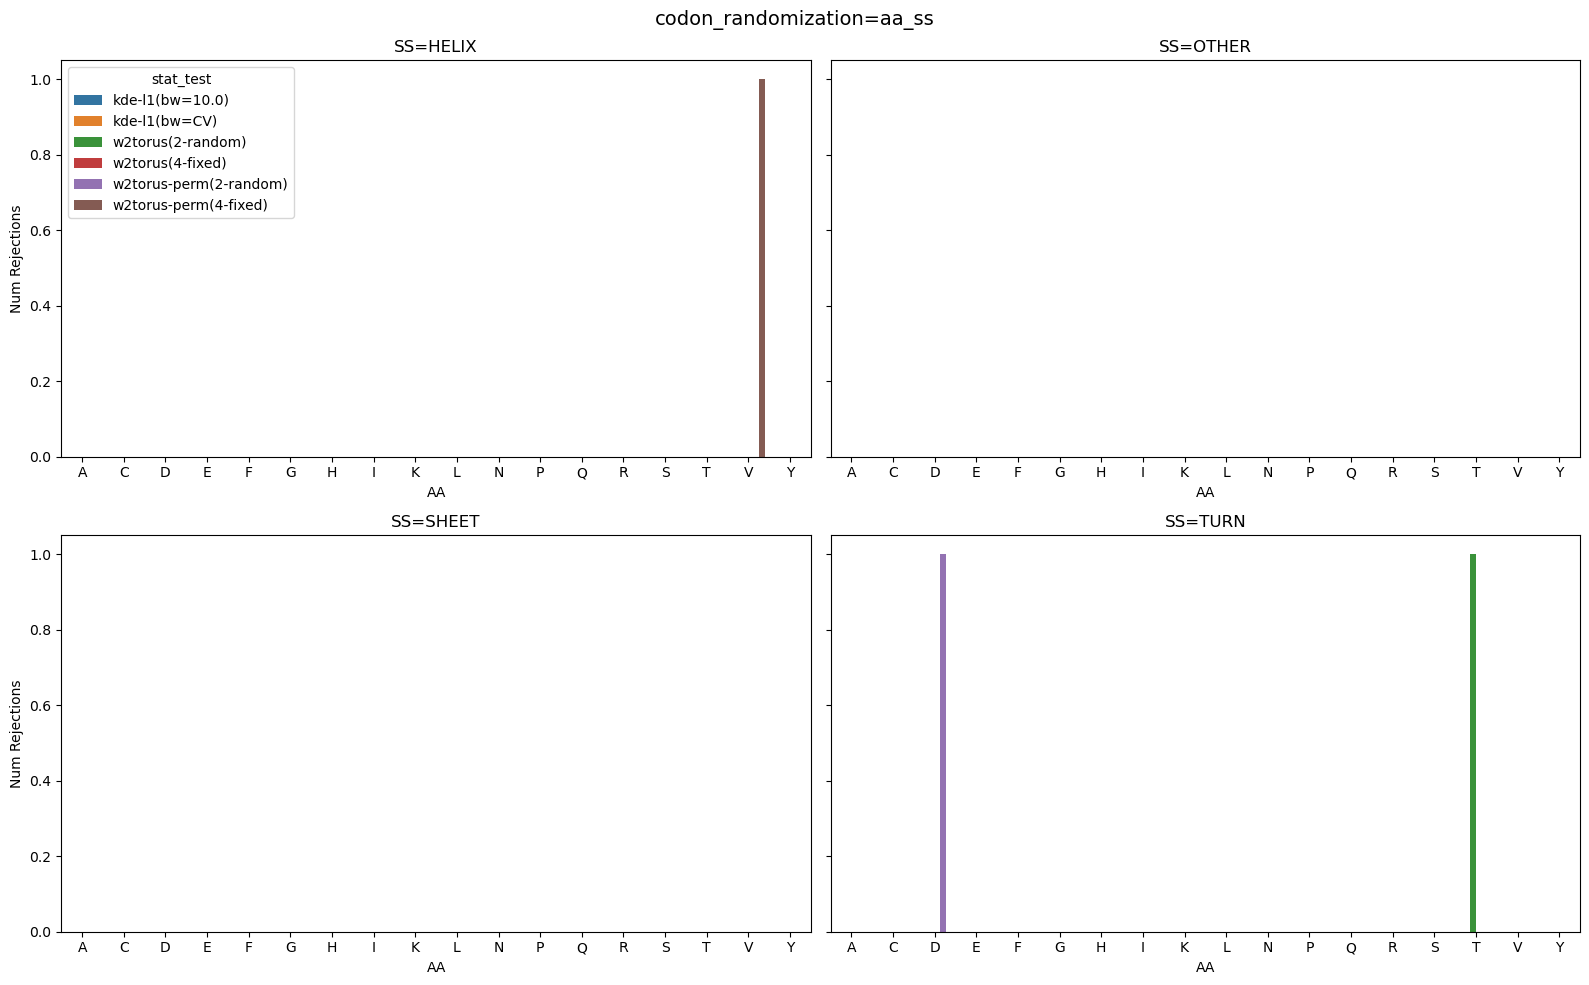

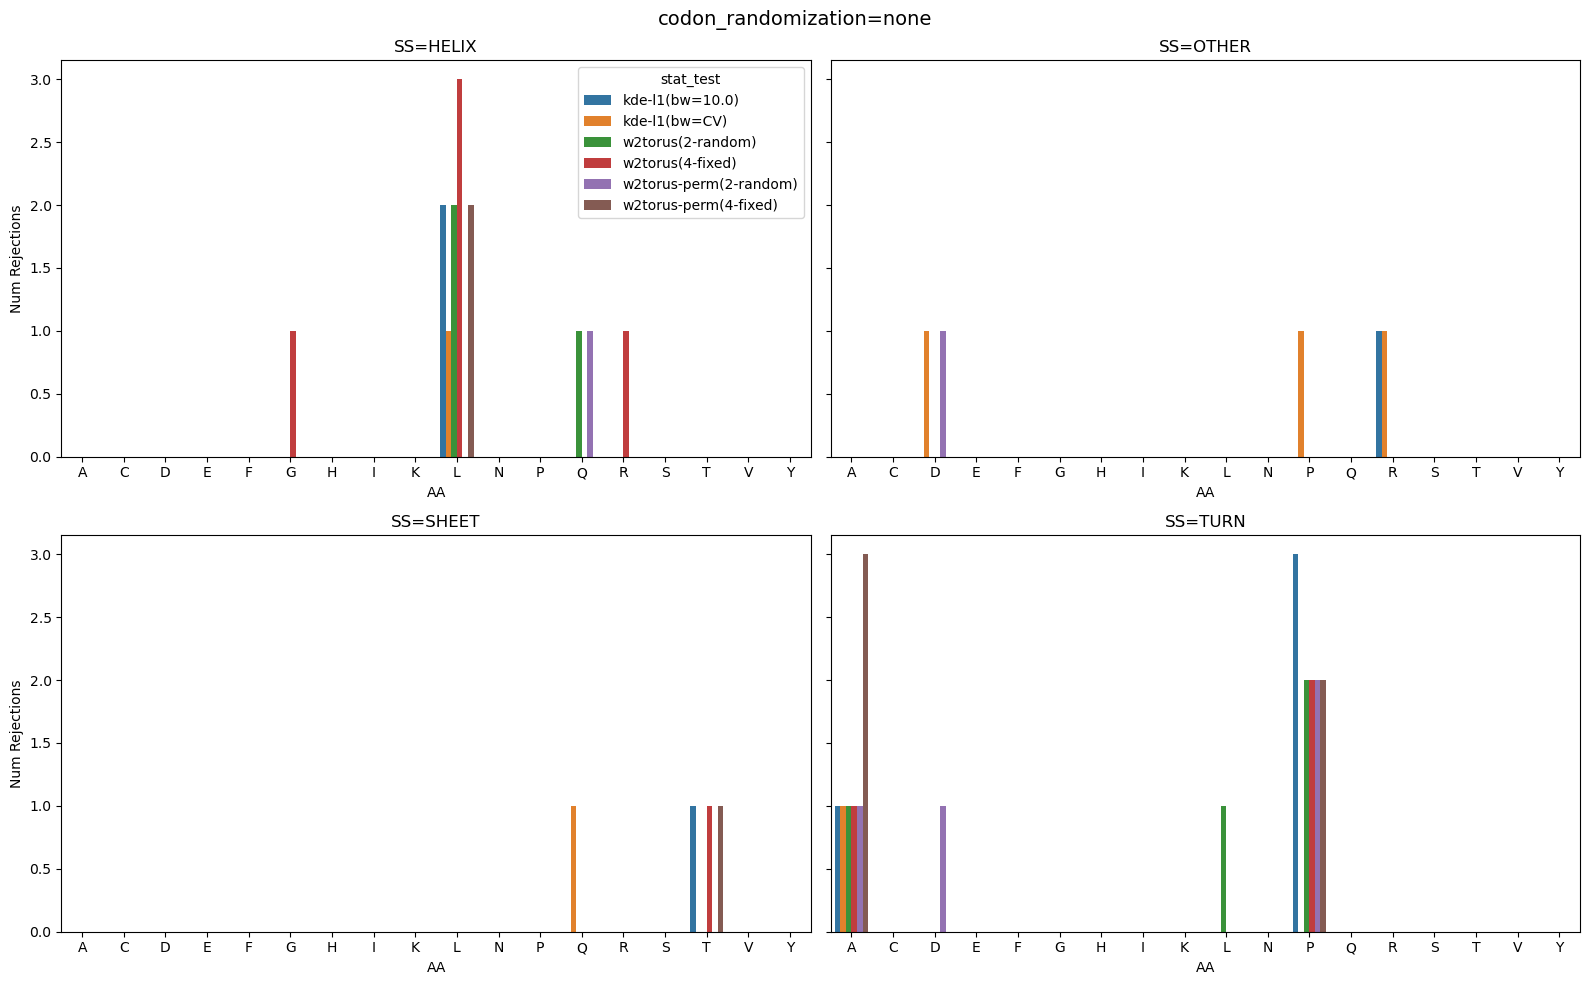

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_rejections_aa.copy()

ALL_AAS = sorted(df["AA"].dropna().unique().tolist())
ALL_SS = sorted(df["SS"].dropna().unique().tolist())
ALL_RAND_TYPES = sorted(df["codon_randomization"].unique().tolist())

assert len(ALL_SS) == 4
assert len(ALL_AAS) == 18  # M and W only have a single codon

# One figure per codon_randomization value, split into four subplots for the AAs
for randomization_type in ALL_RAND_TYPES:
    d = df[df["codon_randomization"] == randomization_type].copy()
    stat_tests = sorted(d["stat_test"].dropna().unique().tolist())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    axes = axes.flatten()
    for i, ss in enumerate(ALL_SS):
        ax = axes[i]
        sub = d[d["SS"] == ss]
        sns.barplot(
            data=sub,
            x="AA",
            y="n_rejected",
            hue="stat_test",
            order=ALL_AAS,
            hue_order=stat_tests,
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"SS={ss}")
        ax.set_xlabel("AA")
        ax.set_ylabel("Num Rejections")
        ax.tick_params(axis="x", rotation=0)
        # legend only on the first subplot
        if i != 0:
            ax.get_legend().remove()
    fig.suptitle(f"codon_randomization={randomization_type}", fontsize=14)
    plt.tight_layout()
    fig.savefig(
        OUT_DIR / f"rejections_aa-randomization={randomization_type}-{FDR=:.2f}.pdf"
    )
    plt.show()
    plt.close(fig)

## Heatmap: BH rejections per (AA × stat-test)

Compare two BH correction strategies side-by-side:

- **Global BH**: threshold determined from all 87 codon-pair p-values within each SS class; per-AA counts are then extracted using that threshold.
- **Per-AA BH**: threshold determined separately within each amino acid's codon pairs.

Each figure is a grid of heatmaps (rows = SS type, columns = Real data / Randomized control).
Within each panel: x-axis = amino acid, y-axis = stat-test configuration,
color = fraction of codon pairs rejected, cell annotation = raw rejection count.


In [33]:
# ── Per-AA rejection counts under the global (across-AA) BH threshold ────────
# The global BH was applied to all 87 codon pairs within each (stat_test,
# randomization, SS) group. Here we re-use the resulting threshold to count,
# for each amino acid separately, how many of its pairs were rejected.
# This gives a per-AA breakdown that is directly comparable to df_rejections_aa
# (where the threshold was determined within each AA independently).

_global_bh_thresh = df_rejections.set_index(["stat_test", "codon_randomization", "SS"])[
    "bh_pvalue_threshold"
]

_rejections_aa_global_entries = []
for (stat_test_name, randomization_type, ss), df_group in df_all_pvals.groupby(
    by=["stat_test", "codon_randomization", "condition_group"], sort=False
):
    # Global BH threshold for this (stat_test, randomization, SS) group
    p_thresh = _global_bh_thresh.loc[(stat_test_name, randomization_type, ss)]

    # Derive the AA letter directly from df_group as a numpy array to avoid
    # index-alignment errors (df_all_pvals has non-unique integer indices because
    # it was built with pd.concat without ignore_index=True).
    aa_arr = df_group["subgroup1"].str.get(0).values  # numpy array of AA letters
    pval_arr = df_group["pval"].values  # numpy array of p-values

    for aa in np.unique(aa_arr):
        mask = aa_arr == aa
        pvals = pval_arr[mask]
        _rejections_aa_global_entries.append(
            {
                "stat_test": stat_test_name,
                "codon_randomization": randomization_type,
                "SS": ss,
                "AA": aa,
                "n_hypotheses": len(pvals),
                "n_rejected": int(np.sum(pvals <= p_thresh)),
            }
        )

df_rejections_aa_global = pd.DataFrame(_rejections_aa_global_entries)
df_rejections_aa_global.head()


,stat_test,codon_randomization,SS,AA,n_hypotheses,n_rejected
0,w2torus(2-random),none,HELIX,A,6,0
1,w2torus(2-random),none,HELIX,C,1,0
2,w2torus(2-random),none,HELIX,D,1,0
3,w2torus(2-random),none,HELIX,E,1,0
4,w2torus(2-random),none,HELIX,F,1,0


In [34]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from pp5.plot import PP5_MPL_STYLE


def _build_rejection_pivots(
    df_rej_aa,
    stat_test_order,
    all_aas,
    ss_order,
    randomization_order,
    value_col="n_rejected",
    as_int=None,
):
    """
    Build pivot tables for the heatmap grid from a per-AA metric DataFrame.

    For each (SS, randomization_type) panel, returns a DataFrame[stat_test × AA]
    with the aggregated value_col metric.

    Parameters
    ----------
    value_col : column in df_rej_aa to pivot on (default 'n_rejected').
    as_int    : cast pivot values to int (default: True only when value_col='n_rejected').
    """
    if as_int is None:
        as_int = value_col == "n_rejected"
    result = {}
    for ss in ss_order:
        for rand in randomization_order:
            sub = df_rej_aa[
                (df_rej_aa["SS"] == ss) & (df_rej_aa["codon_randomization"] == rand)
            ]
            piv = (
                sub.pivot_table(
                    index="stat_test",
                    columns="AA",
                    values=value_col,
                    aggfunc="sum",
                )
                .reindex(index=stat_test_order, columns=all_aas)
                .fillna(0)
            )
            if as_int:
                piv = piv.astype(int)
            result[(ss, rand)] = piv
    return result


In [35]:
def _make_stat_test_labels(df_plot_rows, stat_test_order):
    """
    Build human-readable y-axis labels for each stat_test key.

    Label format: "<test_family> — <test_params>" (or just "<test_family>"
    when there are no parameters, e.g. a baseline method).

    Returns a list of strings aligned with stat_test_order.
    """
    lookup = df_plot_rows.set_index("stat_test")
    labels = []
    for st in stat_test_order:
        if st in lookup.index:
            row = lookup.loc[st]
            family = row["test_family"]
            params = row["test_params"]
            label = f"{family} {params}" if params else family
        else:
            label = st  # fallback to raw key
        labels.append(label)
    return labels


In [47]:
def _plot_rejections_heatmap_grid(
    df_rej_aa,
    stat_test_order,
    all_aas,
    df_plot_rows,
    randomization_order,
    ss_order,
    randomization_display,
    ss_display,
    title,
    vmax,
    vmin=0,
    value_col="n_rejected",
    annot=True,
    annot_fmt=None,
    show_randomized=True,
    cmap="YlOrRd",
    show_cbar=False,
    cbar_label="",
    cbar_threshold=None,
    cbar_threshold_label=None,
    out_path=None,
):
    """
    Plot a grid of metric heatmaps comparing stat tests and amino acids.

    Layout
    ------
    Rows    : SS type (HELIX / SHEET / TURN / OTHER)
    Columns : randomization type (Real data / Randomized control)
              When show_randomized=False only the "Real data" column is shown.

    Each panel
    ----------
    x-axis : amino acid (18 columns)
    y-axis : stat-test configuration (human-readable label)
    color  : value from value_col (vmin → vmax), larger = stronger signal
    text   : same value (formatted with annot_fmt)

    Parameters
    ----------
    df_rej_aa           : DataFrame with columns stat_test, codon_randomization,
                          SS, AA, and value_col.
    vmax                : upper bound of the shared color scale.
    vmin                : lower bound of the color scale (default 0).
    value_col           : column in df_rej_aa to use for heatmap values.
    annot_fmt           : annotation format string (None = auto: 'd' for n_rejected,
                          '.2f' otherwise).
    show_randomized     : if False, only the "Real data" (codon_randomization='none')
                          column is rendered.
    show_cbar           : if True, add a horizontal colorbar below the plot.
    cbar_label          : label text for the colorbar axis.
    cbar_threshold      : if given, mark this value on the colorbar with a dashed
                          line (only drawn when the value falls within [vmin, vmax]).
    cbar_threshold_label: text label for the threshold marker.
    out_path            : if given, the figure is saved there.
    """
    # Auto-detect annotation format
    if annot_fmt is None:
        annot_fmt = "d" if value_col == "n_rejected" else ".2f"

    # Optionally suppress the randomized-control column
    active_rand_order = (
        randomization_order
        if show_randomized
        else [r for r in randomization_order if r == "none"]
    )

    pivots = _build_rejection_pivots(
        df_rej_aa,
        stat_test_order,
        all_aas,
        ss_order,
        active_rand_order,
        value_col=value_col,
    )

    # Human-readable y-axis labels (one per stat_test row)
    yticklabels = _make_stat_test_labels(df_plot_rows, stat_test_order)

    nrows, ncols = len(ss_order), len(active_rand_order)
    n_aa = len(all_aas)
    n_st = len(stat_test_order)

    # Heuristic figure size: ~0.52" per AA cell × ncols panels, ~0.48" per stat-test row
    fig_w = 0.52 * n_aa * ncols + 3.0
    fig_h = 0.52 * n_st * nrows + 2.0
    if show_cbar:
        fig_h += 0.6  # extra vertical room for the colorbar

    plt.close("all")
    with mpl.style.context(PP5_MPL_STYLE):
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(fig_w, fig_h),
            squeeze=False,
        )
        bottom_adj = 0.14 if show_cbar else 0.06
        fig.subplots_adjust(hspace=0.65, wspace=0.10, bottom=bottom_adj)

        for row_idx, ss in enumerate(ss_order):
            for col_idx, rand in enumerate(active_rand_order):
                ax = axes[row_idx, col_idx]
                piv = pivots[(ss, rand)]

                sns.heatmap(
                    piv,
                    ax=ax,
                    vmin=vmin,
                    vmax=vmax,
                    cmap=cmap,
                    annot=annot,  # annotate with the metric value
                    fmt=annot_fmt,
                    annot_kws={"fontsize": 7},
                    linewidths=0.35,
                    linecolor="0.88",
                    cbar=False,  # colorbar added separately below
                    xticklabels=True,
                    yticklabels=(col_idx == 0),  # y labels only on first column
                )

                if col_idx == 0:
                    ax.set_yticklabels(yticklabels, rotation=0, fontsize=7)

                ax.set_xlabel("")
                ax.set_ylabel("")
                ax.tick_params(axis="x", labelsize=8, rotation=0)

                # Column header: human-readable randomization label (top row only)
                if row_idx == 0:
                    ax.set_title(
                        randomization_display.get(rand, rand),
                        fontweight="bold",
                        fontsize=10,
                        pad=8,
                    )

                # Row label: SS type — to the right of the last column
                if col_idx == ncols - 1:
                    ax.annotate(
                        ss_display.get(ss, ss),
                        xy=(1.02, 0.5),
                        xycoords="axes fraction",
                        ha="left",
                        va="center",
                        fontsize=10,
                        fontweight="bold",
                        annotation_clip=False,
                    )

        fig.suptitle(title, fontsize=12, fontweight="bold", y=0.95)

        # Optional horizontal colorbar spanning the width of the subplot grid
        if show_cbar:
            import matplotlib.colors as mcolors

            # Use actual axis positions so the colorbar aligns with the grid
            all_ax_pos = [ax.get_position() for ax in axes.flat]
            cb_left = min(p.x0 for p in all_ax_pos)
            cb_right = max(p.x1 for p in all_ax_pos)

            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])

            cbar_ax = fig.add_axes([cb_left, 0.01, cb_right - cb_left, 0.025])
            cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
            cb.set_label(cbar_label, fontsize=9)

            # Threshold marker: only drawn when the value falls within [vmin, vmax]
            if cbar_threshold is not None and vmin <= cbar_threshold <= vmax:
                cb.ax.axvline(x=cbar_threshold, color="black", lw=1.5, ls="--")
                if cbar_threshold_label:
                    cb.ax.text(
                        cbar_threshold,
                        1.8,
                        cbar_threshold_label,
                        transform=cb.ax.get_xaxis_transform(),
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        color="black",
                    )

        if out_path is not None:
            fig.savefig(out_path, bbox_inches="tight")
            print(f"Saved: {out_path}")

        plt.show()

    return fig


Heatmap vmax (max rejections): 3
Saved: /Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs/rejections_heatmap-cross_aa-FDR=0.05.pdf


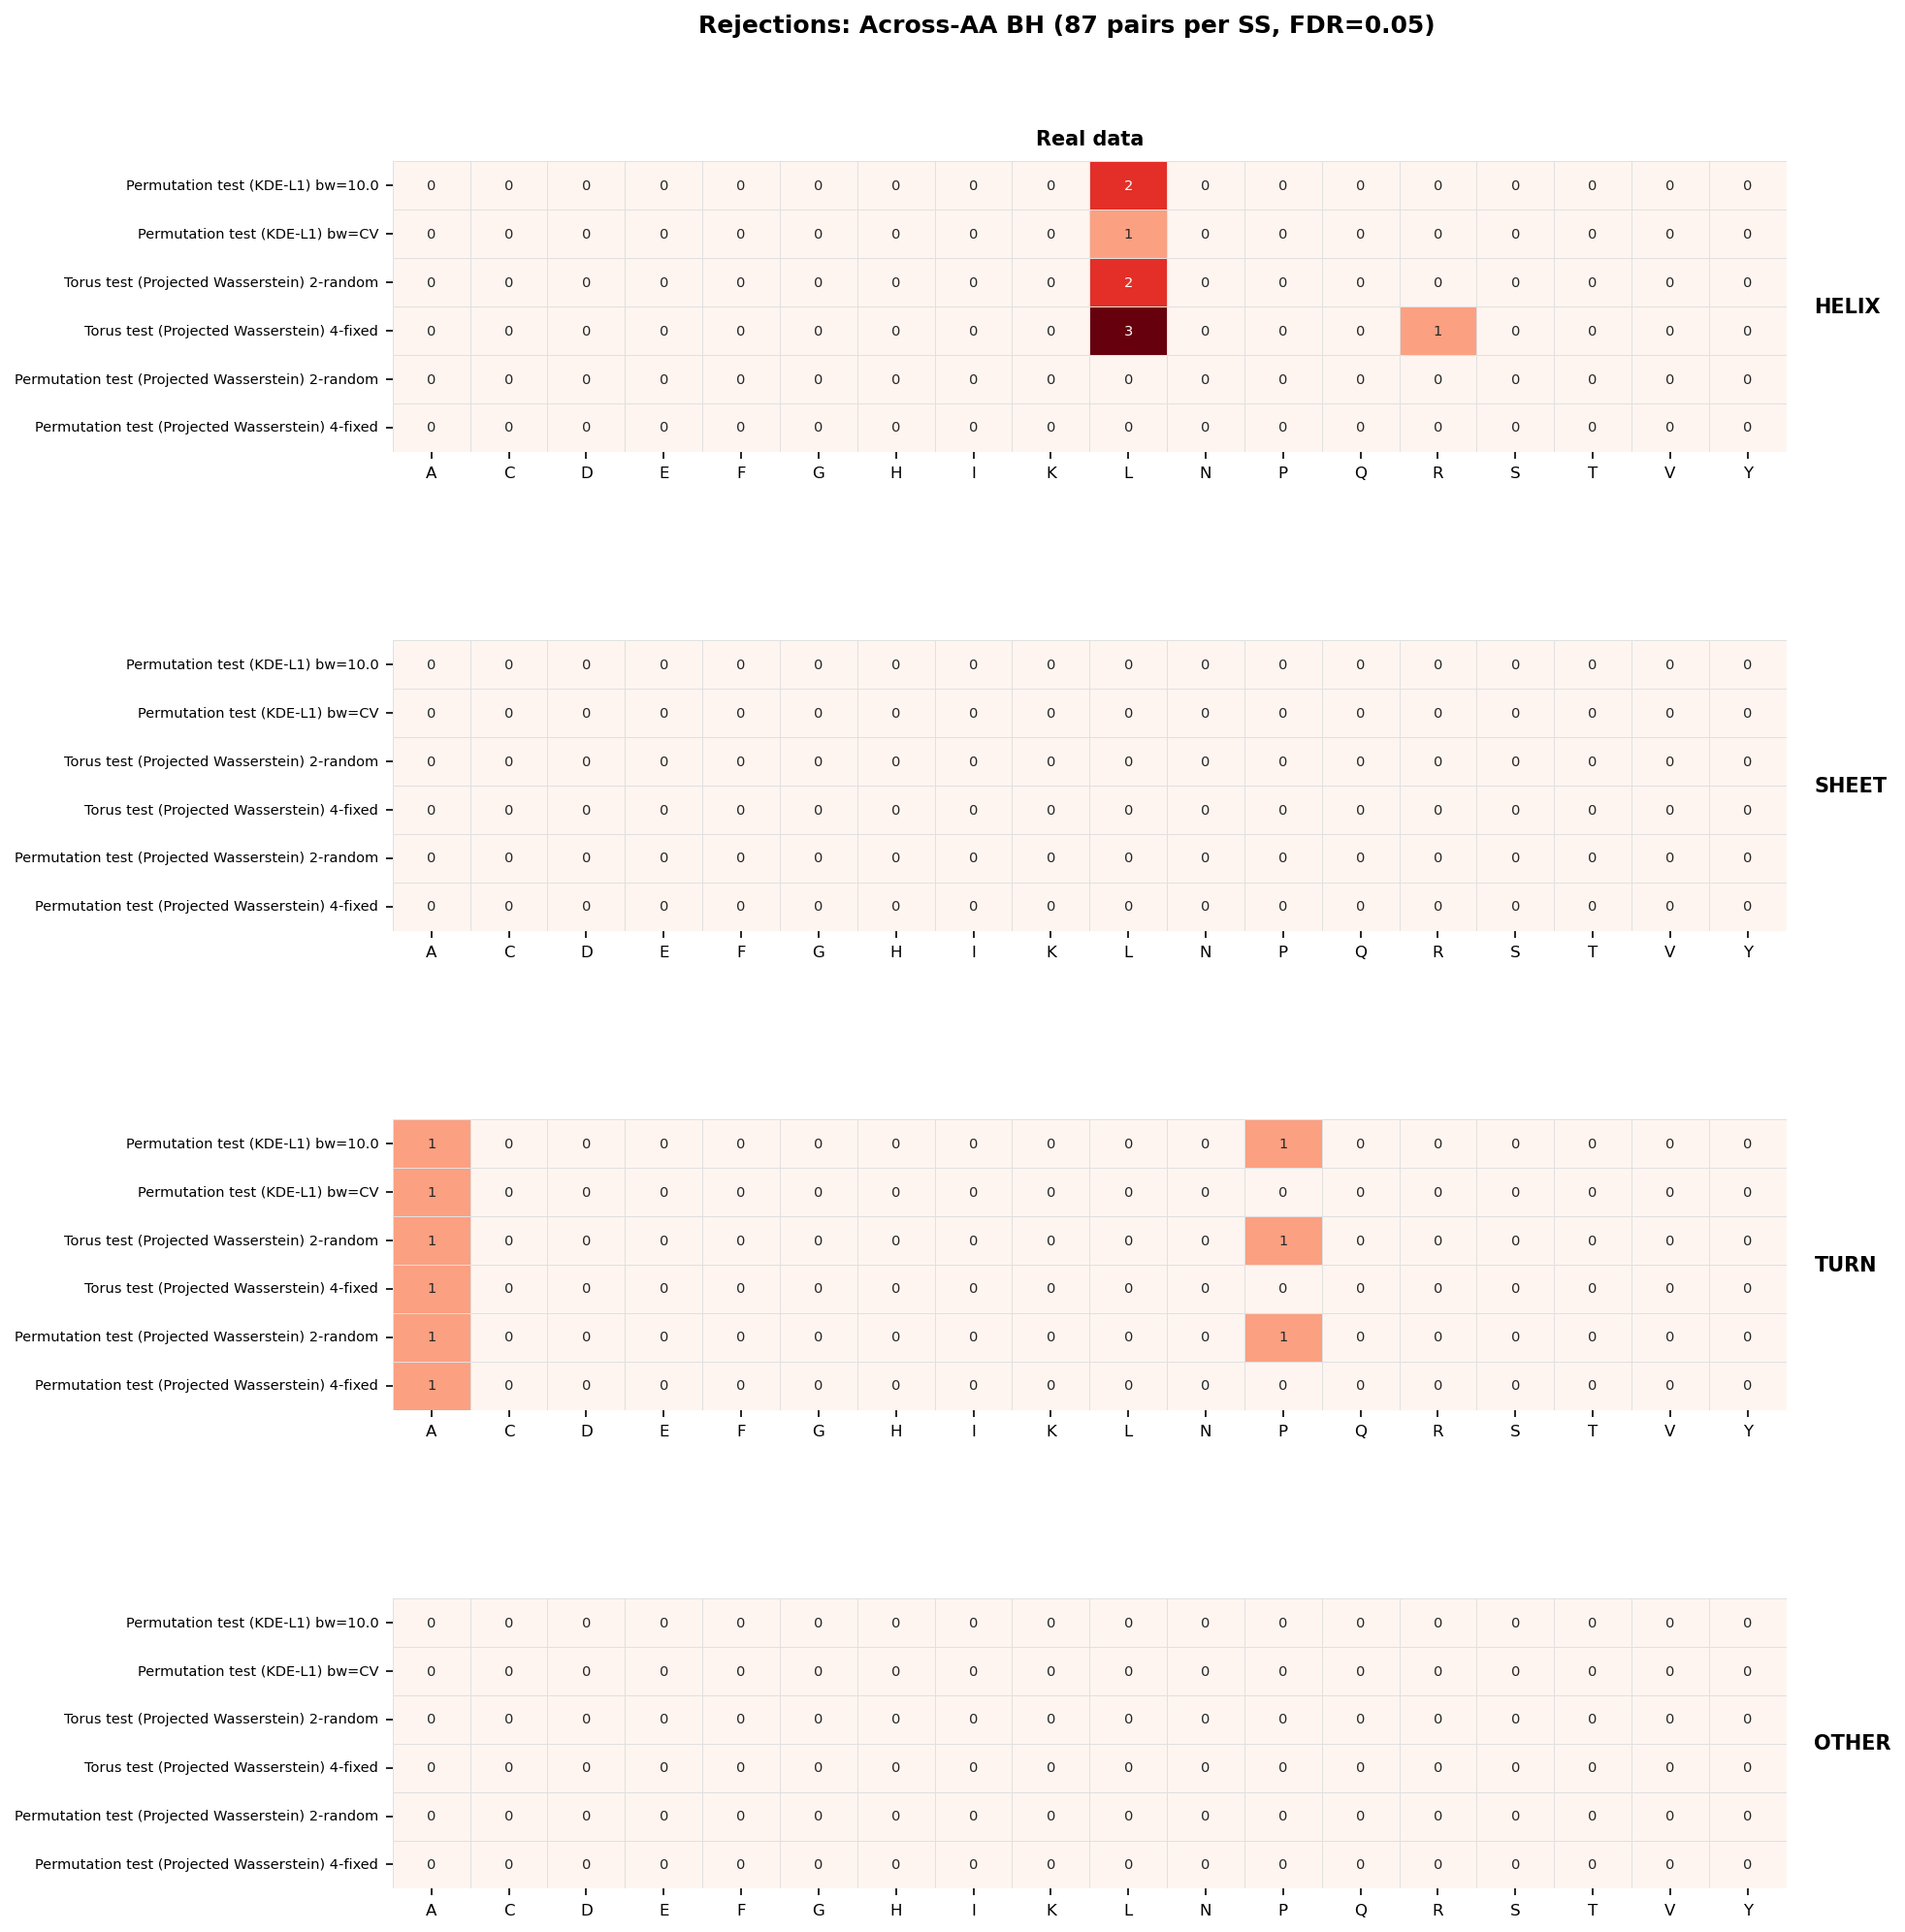

In [48]:
# Shared color scale: vmax = largest n_rejected across both BH strategies,
# all stat tests, all AAs and all randomization types, so the two figures
# are directly comparable on the same color axis.
_vmax_heatmap = int(
    max(
        df_rejections_aa_global["n_rejected"].max(),
        df_rejections_aa["n_rejected"].max(),
    )
)
print(f"Heatmap vmax (max rejections): {_vmax_heatmap}")

cmap = "Reds"

# Figure 1: Global BH — threshold set across all 87 codon pairs per SS class,
# then per-AA counts extracted.  Shows where signal lives *after* a stricter,
# pooled correction that accounts for all AAs simultaneously.
fig_global = _plot_rejections_heatmap_grid(
    df_rej_aa=df_rejections_aa_global,
    stat_test_order=stat_test_order,
    all_aas=ALL_AAS,
    df_plot_rows=df_plot_rows,
    randomization_order=randomization_order,
    ss_order=ss_order,
    randomization_display=randomization_display,
    ss_display=ss_display,
    title=f"Rejections: Across-AA BH (87 pairs per SS, FDR={FDR})",
    vmax=_vmax_heatmap,
    show_randomized=False,  # set to True to also show the randomized-control column
    cmap=cmap,
    out_path=OUT_DIR / f"rejections_heatmap-cross_aa-{FDR=:.2f}.pdf",
)


Saved: /Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs/rejections_heatmap-within_aa_bh-FDR=0.05.pdf


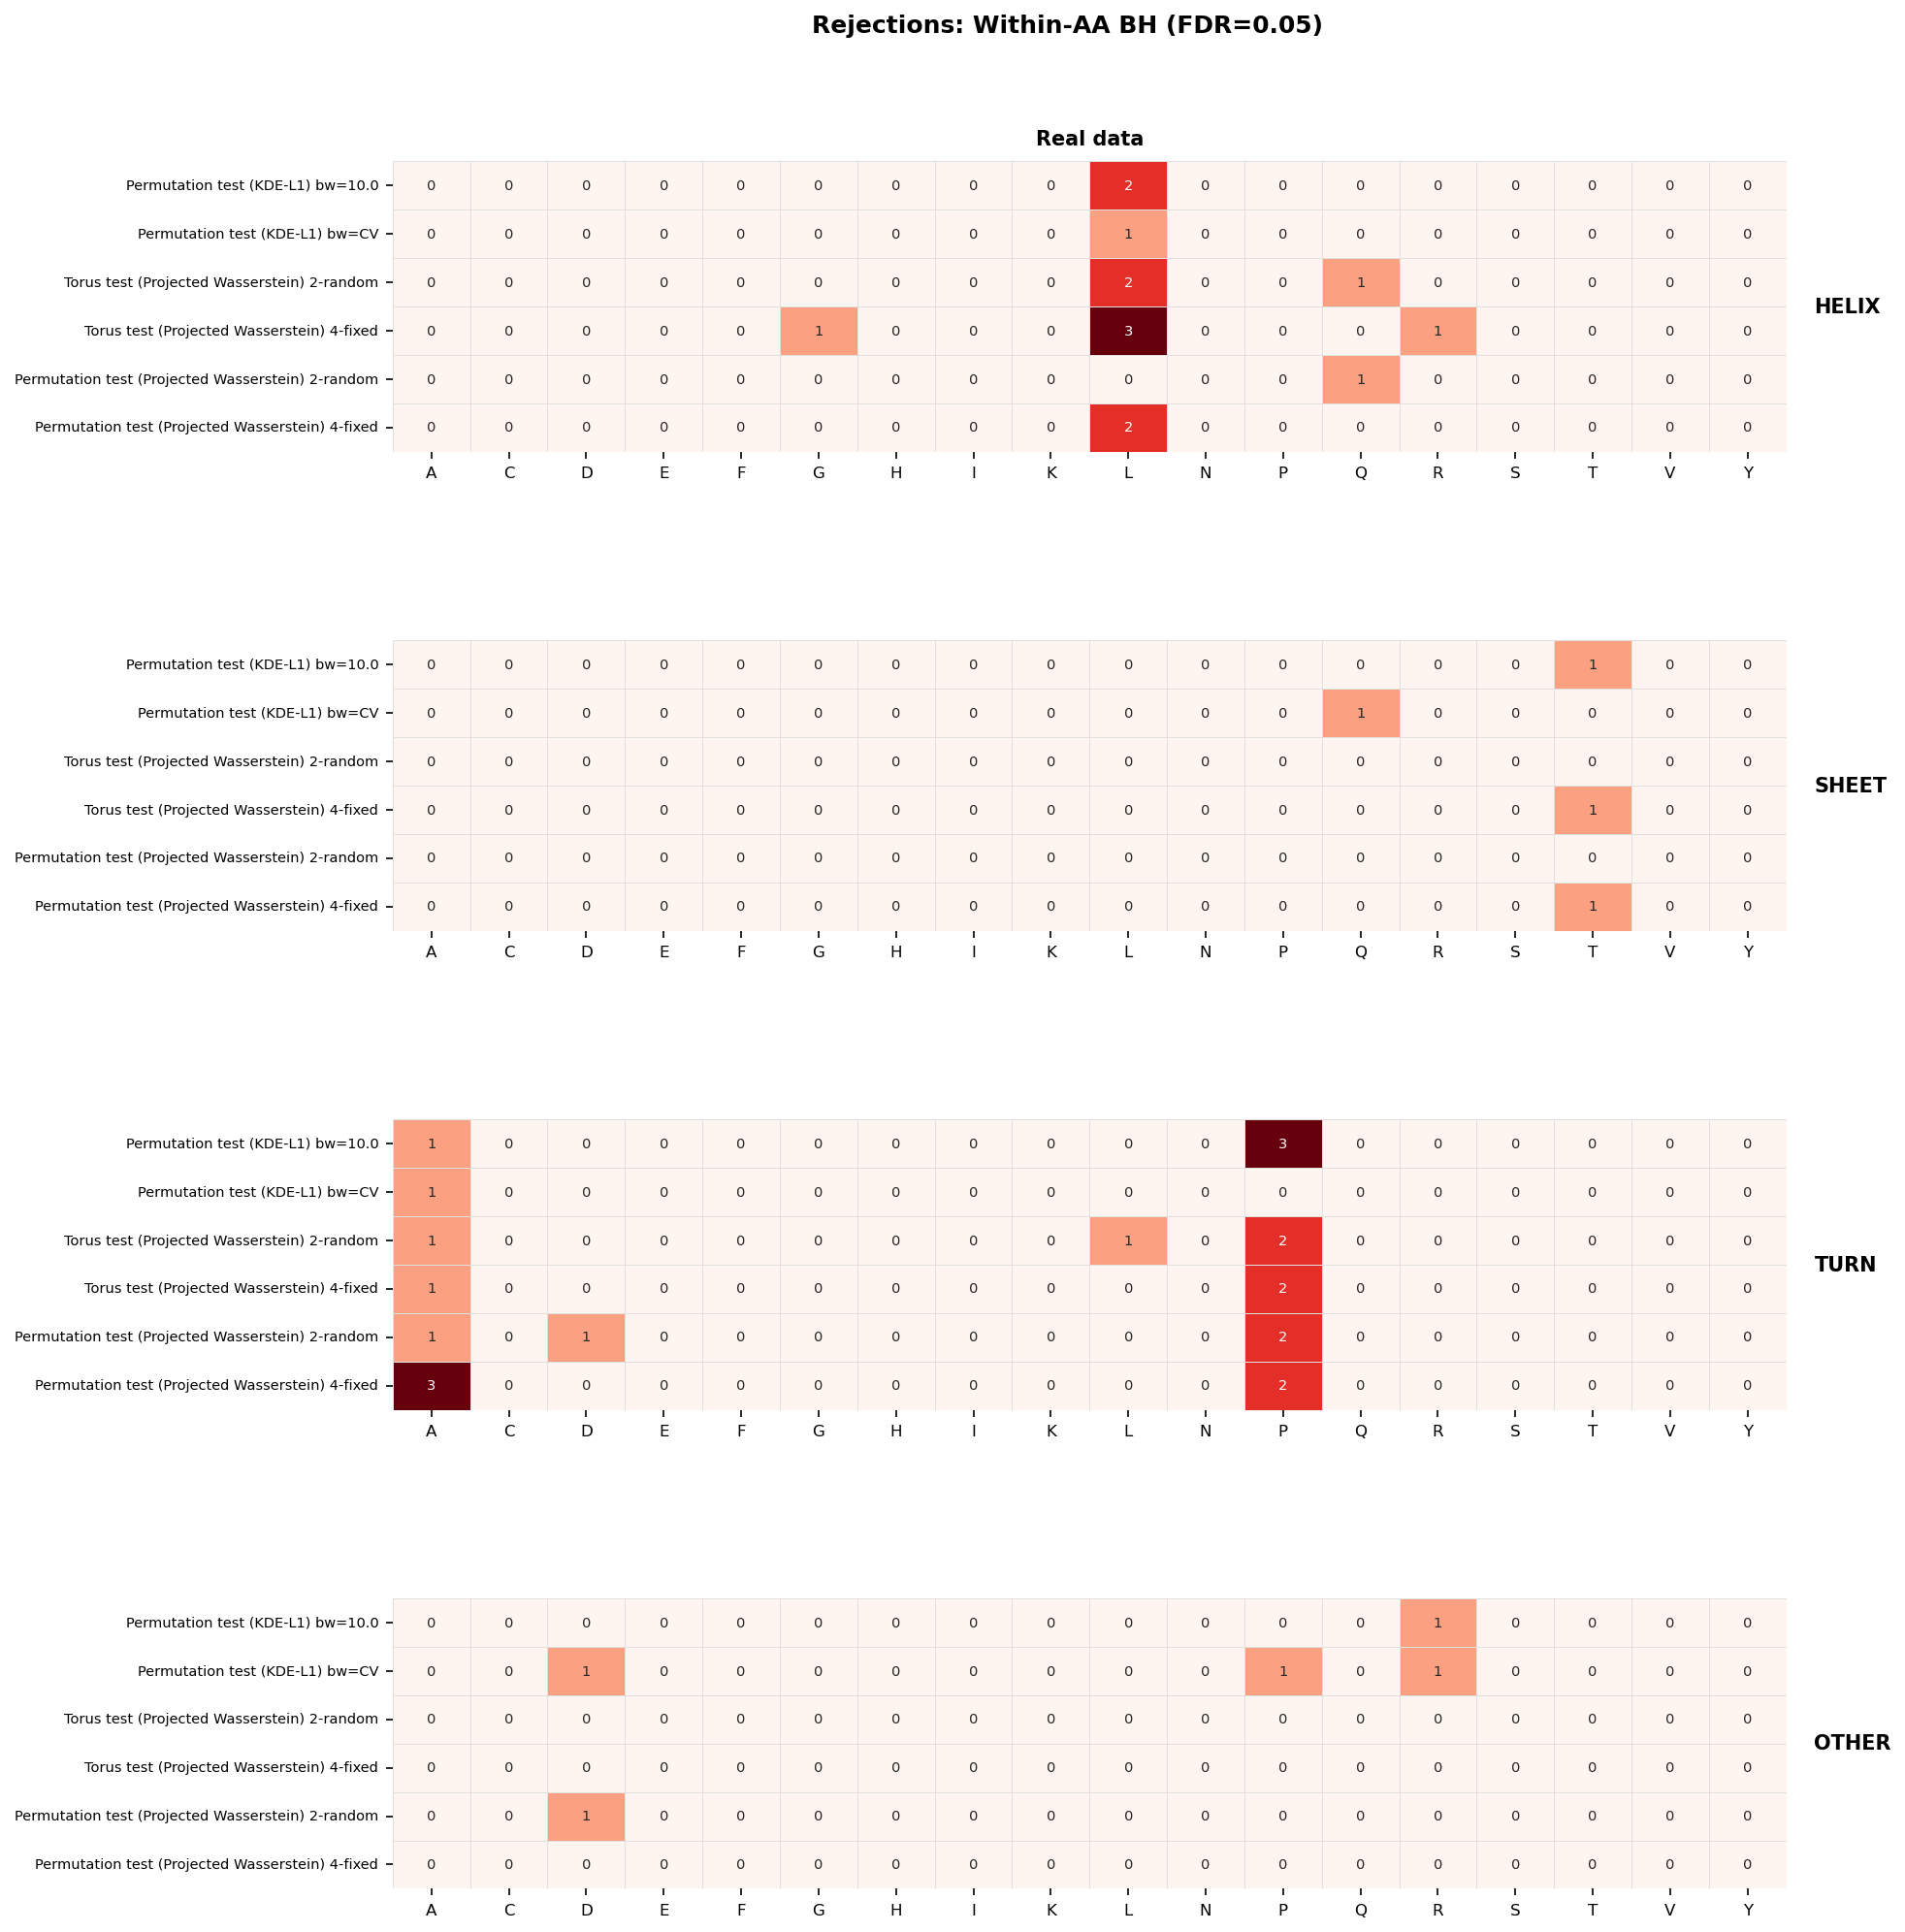

In [49]:
# Figure 2: Per-AA BH — threshold set separately within each amino acid's codon
# pairs.  A less stringent correction for large AA families; more sensitive but
# more prone to false positives in the randomized control.
from matplotlib.pylab import cm

fig_within = _plot_rejections_heatmap_grid(
    df_rej_aa=df_rejections_aa,
    stat_test_order=stat_test_order,
    all_aas=ALL_AAS,
    df_plot_rows=df_plot_rows,
    randomization_order=randomization_order,
    ss_order=ss_order,
    randomization_display=randomization_display,
    ss_display=ss_display,
    title=f"Rejections: Within-AA BH (FDR={FDR})",
    vmax=_vmax_heatmap,
    show_randomized=False,  # set to True to also show the randomized-control column
    cmap=cmap,
    out_path=OUT_DIR / f"rejections_heatmap-within_aa_bh-{FDR=:.2f}.pdf",
)


### Heatmap: p-value metric per (AA × stat-test)

Compare p-value signal strength across amino acids, SS types and statistical tests
using several aggregation metrics.  All metrics are on a $-\log_{10}$ scale so
**larger = more signal** (darker cell = stronger evidence against the null).

| Metric | Formula | Notes |
|--------|---------|-------|
| Geometric mean | $\bar{s} = \frac{1}{m}\sum -\log_{10} p_i$ | Balances all pairs; robust to outliers |
| Harmonic mean | $-\log_{10}\!\left(\frac{m}{\sum 1/p_i}\right)$ | Up-weights the smallest p-values |
| Minimum | $-\log_{10}(\min p_i)$ | Tracks the single strongest pair |
| Median | $-\log_{10}(\text{median}\, p_i)$ | Robust central tendency |
| # Rejected (BH) | count of pairs with $p \le p^*_\text{BH}$ | Existing binary criterion |

The dashed line on each colorbar marks $-\log_{10}(0.05) \approx 1.30$, the conventional significance threshold.


In [62]:
_NEGLOG05 = -np.log10(0.05)  # ≈ 1.301 — significance threshold on the -log10 scale

# Configuration for each supported p-value aggregation metric.
# Each entry drives both the compute step and the heatmap plot options.
PVAL_METRIC_CONFIGS = {
    "geom_mean": {
        "label": r"Geometric mean ($-\log_{10}\,p$)",
        "cbar_label": r"$-\log_{10}$(geometric mean $p$)",
        "cbar_threshold": _NEGLOG05,
        "cbar_threshold_label": r"$p=0.05$",
        "vmin": 0.0,
        "cmap": "Blues",
        "annot_fmt": ".2f",
    },
    "harm_mean": {
        "label": r"Harmonic mean ($-\log_{10}\,p$)",
        "cbar_label": r"$-\log_{10}$(harmonic mean $p$)",
        "cbar_threshold": _NEGLOG05,
        "cbar_threshold_label": r"$p=0.05$",
        "vmin": 0.0,
        "cmap": "Blues",
        "annot_fmt": ".2f",
    },
    "minimum": {
        "label": r"Minimum ($-\log_{10}\,p$)",
        "cbar_label": r"$-\log_{10}$(min $p$)",
        "cbar_threshold": _NEGLOG05,
        "cbar_threshold_label": r"$p=0.05$",
        "vmin": 0.0,
        "cmap": "Blues",
        "annot_fmt": ".2f",
    },
    "median": {
        "label": r"Median ($-\log_{10}\,p$)",
        "cbar_label": r"$-\log_{10}$(median $p$)",
        "cbar_threshold": _NEGLOG05,
        "cbar_threshold_label": r"$p=0.05$",
        "vmin": 0.0,
        "cmap": "Blues",
        "annot_fmt": ".2f",
    },
    "n_rejected": {
        "label": f"Rejections (BH FDR={FDR:.2f})",
        "cbar_label": "# rejected codon pairs",
        "cbar_threshold": None,
        "cbar_threshold_label": None,
        "vmin": 0,
        "cmap": "Reds",
        "annot_fmt": "d",
    },
}


In [63]:
def compute_pval_metric_df(
    df_all_pvals,
    metric,
    bh_thresh_series=None,
    eps: float = 1 / 5000.0,  # 1e-30,
):
    """
    Compute a scalar p-value summary metric per (stat_test, codon_randomization, SS, AA).

    All -log10 metrics clip p-values to [eps, 1] before taking the log to avoid
    inf/-inf values.

    Parameters
    ----------
    df_all_pvals    : long-form DataFrame with columns pval, subgroup1,
                      stat_test, codon_randomization, condition_group.
    metric          : one of 'geom_mean', 'harm_mean', 'minimum', 'median',
                      'n_rejected'.
    bh_thresh_series: required for metric='n_rejected'; Series indexed by
                      (stat_test, codon_randomization, SS) giving the BH threshold.

    Returns
    -------
    DataFrame with columns: stat_test, codon_randomization, SS, AA, value.
    """
    if metric == "n_rejected" and bh_thresh_series is None:
        raise ValueError("bh_thresh_series is required for metric='n_rejected'")

    entries = []
    for (stat_test, rand, ss), df_ss in df_all_pvals.groupby(
        ["stat_test", "codon_randomization", "condition_group"], sort=False
    ):
        aa_arr = df_ss["subgroup1"].str.get(0).values
        pval_arr = df_ss["pval"].values

        if metric == "n_rejected":
            p_thresh = bh_thresh_series.loc[(stat_test, rand, ss)]

        for aa in np.unique(aa_arr):
            pvals = pval_arr[aa_arr == aa]
            pvals_clipped = np.clip(pvals, eps, 1.0)

            if metric == "geom_mean":
                # Mean of -log10(p) = -log10(geometric mean of p)
                val = float(np.mean(-np.log10(pvals_clipped)))
            elif metric == "harm_mean":
                # Harmonic mean p-value: m / sum(1/p_i)
                m = len(pvals)
                hmp = m / np.sum(1.0 / pvals_clipped)
                val = float(-np.log10(np.clip(hmp, eps, 1.0)))
            elif metric == "minimum":
                val = float(-np.log10(np.min(pvals_clipped)))
            elif metric == "median":
                val = float(-np.log10(np.median(pvals_clipped)))
            elif metric == "n_rejected":
                val = int(np.sum(pvals <= p_thresh))
            else:
                raise ValueError(f"Unknown metric: {metric!r}")

            entries.append(
                {
                    "stat_test": stat_test,
                    "codon_randomization": rand,
                    "SS": ss,
                    "AA": aa,
                    "value": val,
                }
            )

    return pd.DataFrame(entries)


Saved: /Users/avivr/dev/technion/phd/pp5/out/pnas-2026/figs/pval_metric_heatmap-harm_mean.pdf


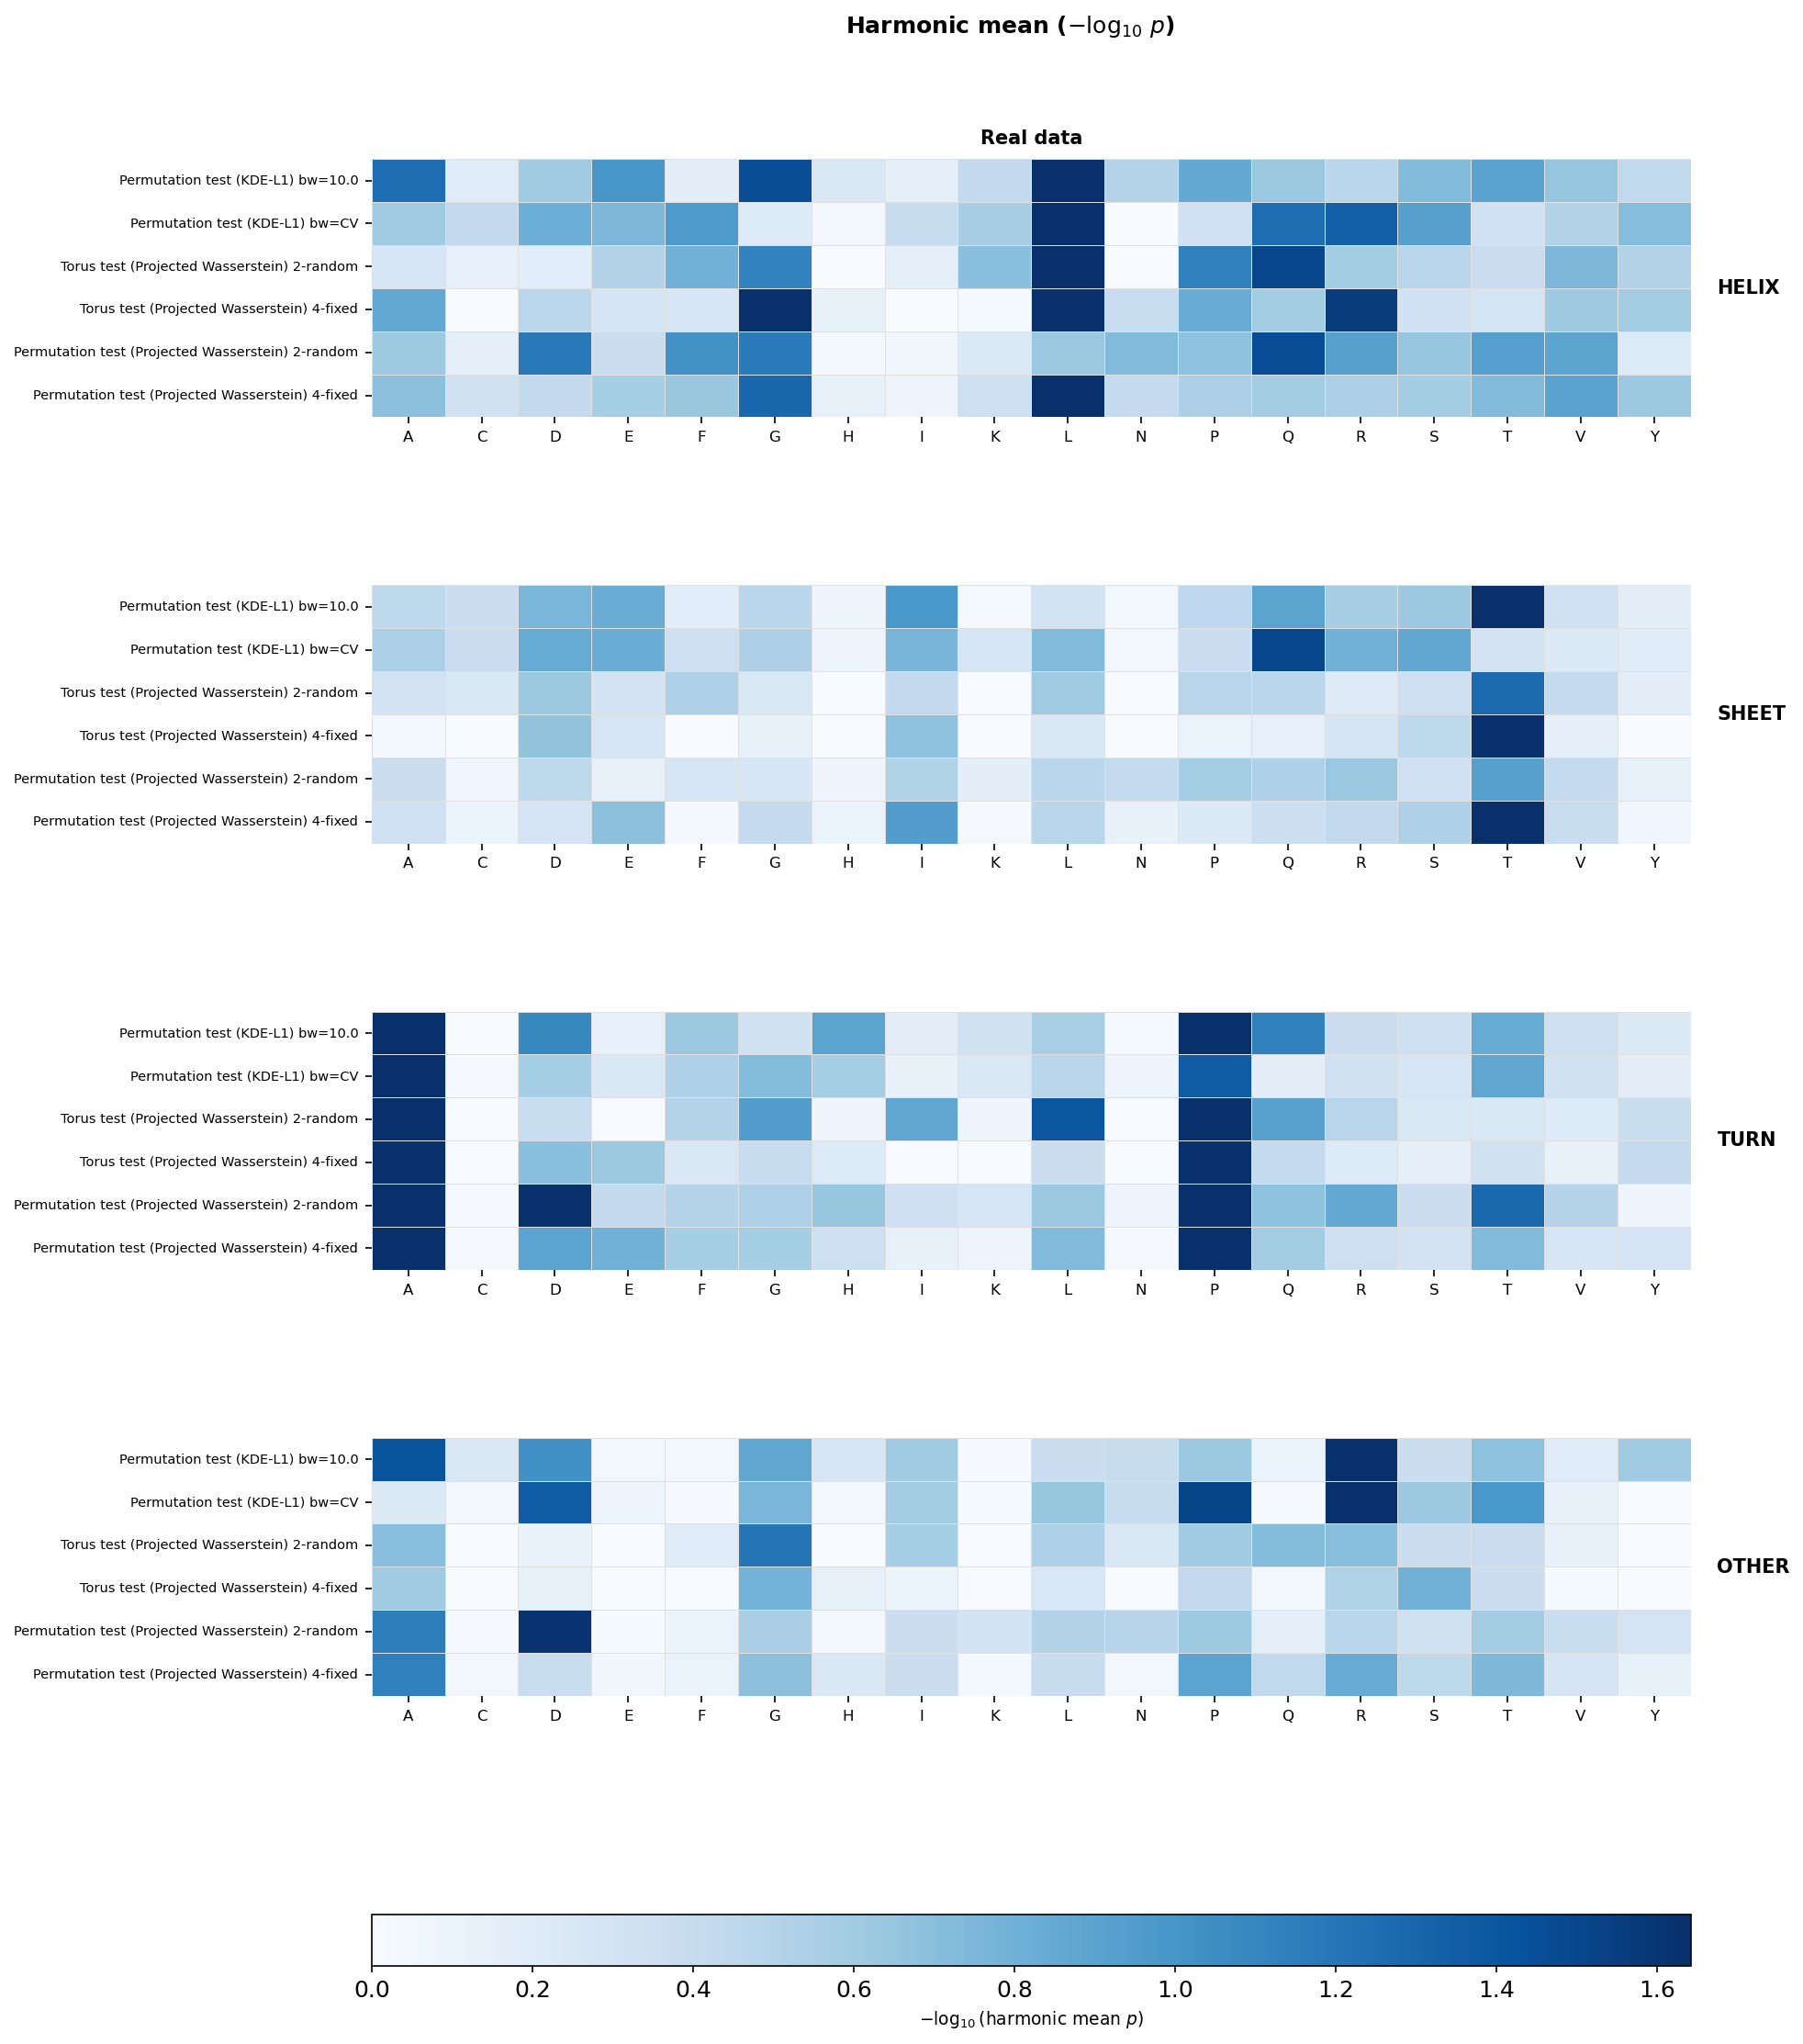

In [64]:
# ── Plot one heatmap figure per p-value metric ────────────────────────────────
# For each metric the vmax is the 95th percentile of real-data values (capped
# at a minimum that ensures the significance threshold is visible on the colorbar).
# Using the 95th percentile keeps the color scale meaningful even when a handful
# of cells reach extreme values (e.g. -log10(~0) ≈ 300 for 'minimum').
# For sparse data such as n_rejected (mostly zeros), the percentile falls to 0
# so we fall back to the actual maximum in that case.

_PLOT_METRICS = [
    # "geom_mean",
    "harm_mean",
    # "minimum",
    # "median",
    # "n_rejected",
]

_bh_thresh_for_metric = df_rejections.set_index(
    ["stat_test", "codon_randomization", "SS"]
)["bh_pvalue_threshold"]

for metric_name in _PLOT_METRICS:
    mcfg = PVAL_METRIC_CONFIGS[metric_name]

    df_metric = compute_pval_metric_df(
        df_all_pvals,
        metric=metric_name,
        bh_thresh_series=_bh_thresh_for_metric if metric_name == "n_rejected" else None,
    )

    # vmax from real-data column only
    real_vals = df_metric.loc[df_metric["codon_randomization"] == "none", "value"]
    vmax_metric = float(np.percentile(real_vals, 95))
    # Sparse distributions (e.g. n_rejected) may have a 95th-percentile of 0;
    # fall back to the actual maximum so the colorbar is meaningful.
    if vmax_metric == 0:
        vmax_metric = float(real_vals.max())
    # Ensure the threshold marker (if any) is visible within the scale
    if mcfg.get("cbar_threshold") is not None:
        vmax_metric = max(vmax_metric, mcfg["cbar_threshold"] * 1.1)
    vmax_metric = max(vmax_metric, mcfg["vmin"] + 0.01)  # guard against zero range

    _plot_rejections_heatmap_grid(
        df_rej_aa=df_metric,
        stat_test_order=stat_test_order,
        all_aas=ALL_AAS,
        df_plot_rows=df_plot_rows,
        randomization_order=randomization_order,
        ss_order=ss_order,
        randomization_display=randomization_display,
        ss_display=ss_display,
        title=mcfg["label"],
        vmax=vmax_metric,
        vmin=mcfg["vmin"],
        value_col="value",
        annot=metric_name == "n_rejected",
        annot_fmt=mcfg["annot_fmt"],
        show_randomized=False,
        cmap=mcfg["cmap"],
        show_cbar=metric_name != "n_rejected",
        cbar_label=mcfg["cbar_label"],
        # cbar_threshold=mcfg.get("cbar_threshold"),
        # cbar_threshold_label=mcfg.get("cbar_threshold_label"),
        out_path=OUT_DIR / f"pval_metric_heatmap-{metric_name}.pdf",
    )
